In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('loan_prediction.csv')

# Basic exploration
print("Shape:", df.shape)


Shape: (614, 13)


In [3]:

print(df.head())


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [4]:

print("\nColumn Data Types:")
print(df.dtypes)



Column Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [5]:

print("\nBasic Statistics:")
print(df.describe())



Basic Statistics:
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [6]:

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


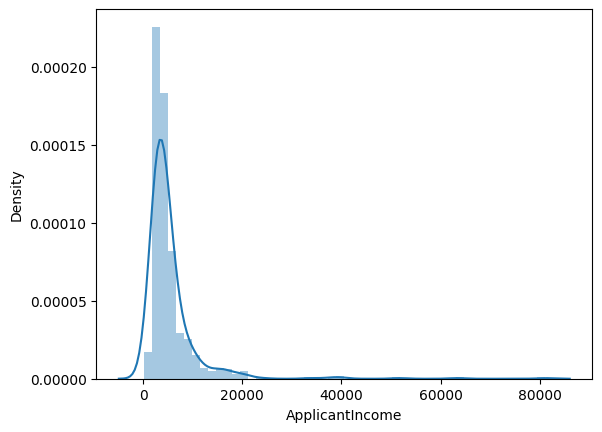

In [20]:

import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
sns.distplot(df['ApplicantIncome'])
plt.show()

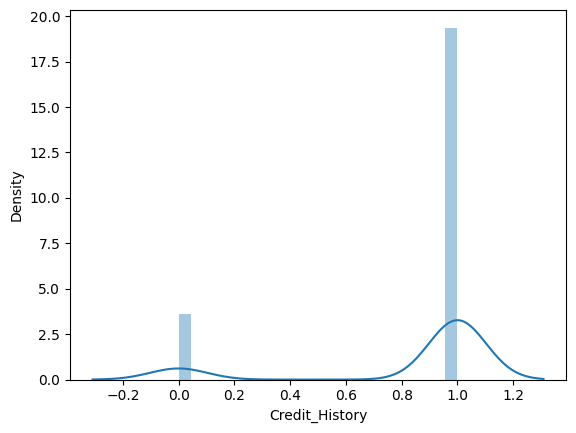

In [22]:
sns.distplot(df['Credit_History'])
plt.show()

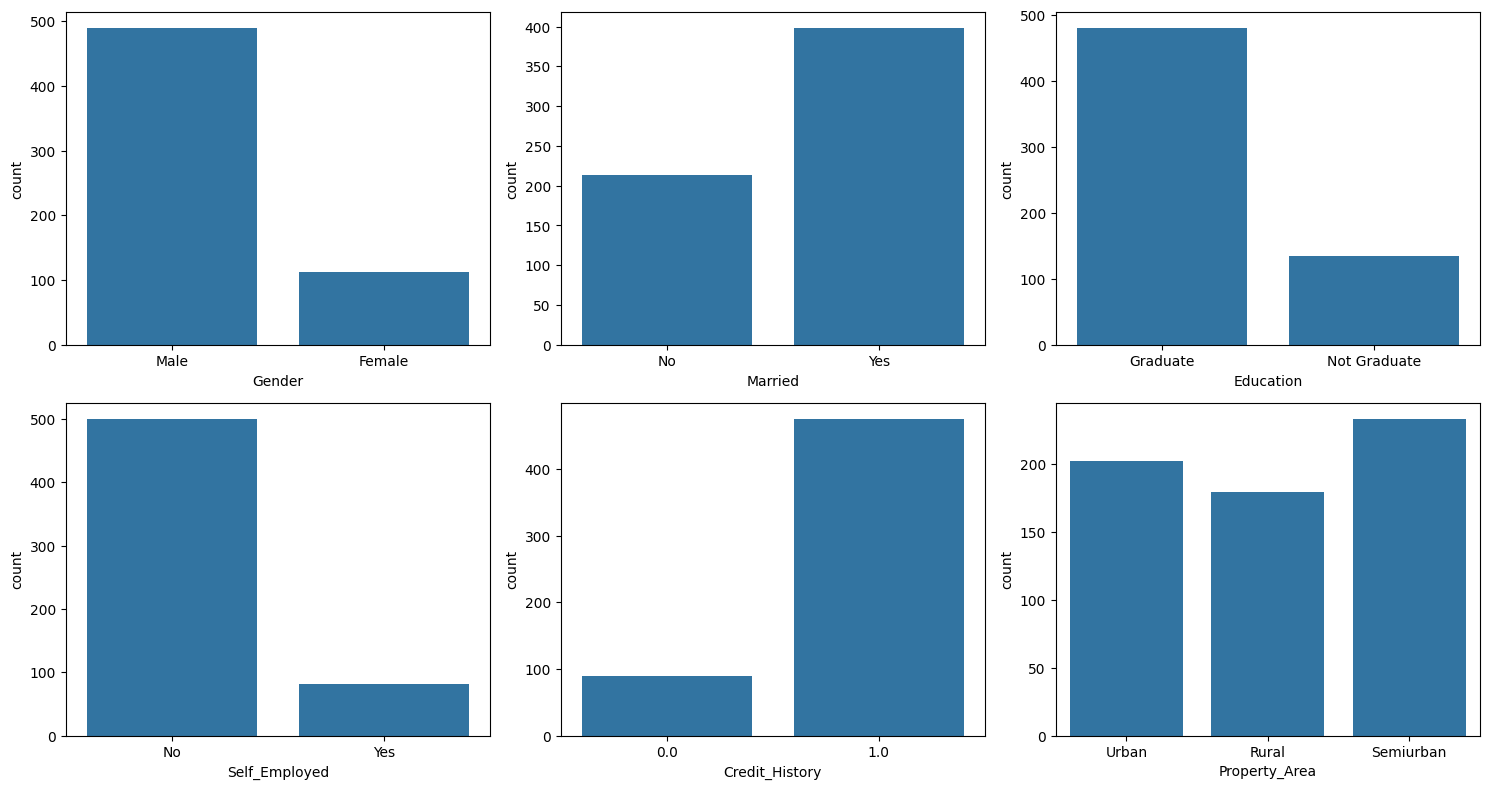

In [21]:
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i//3, i%3])
plt.tight_layout()
plt.show()

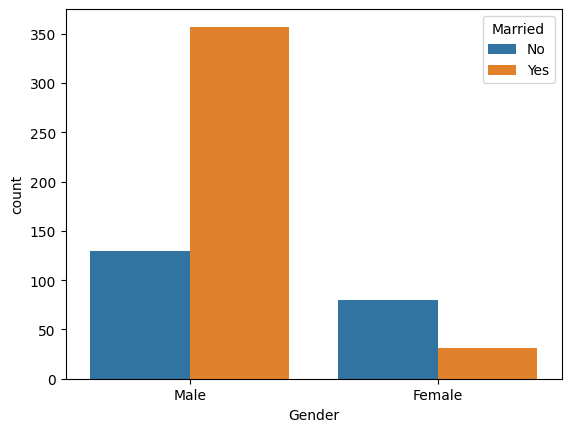

In [23]:
sns.countplot(x='Gender', hue='Married', data=df)
plt.show()


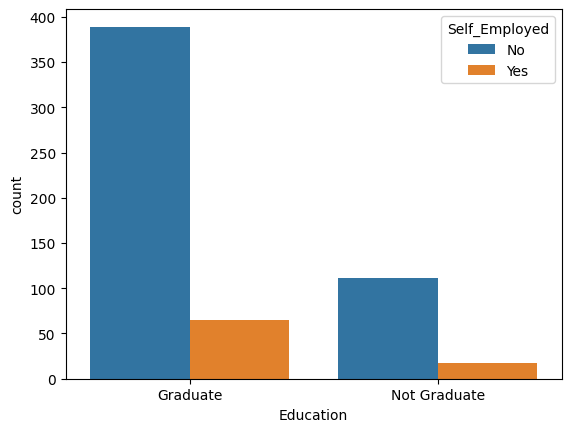

In [24]:

sns.countplot(x='Education', hue='Self_Employed', data=df)
plt.show()


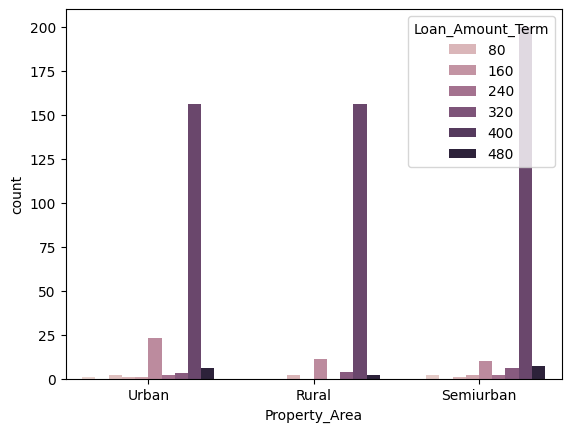

In [25]:

sns.countplot(x='Property_Area', hue='Loan_Amount_Term', data=df)
plt.show()

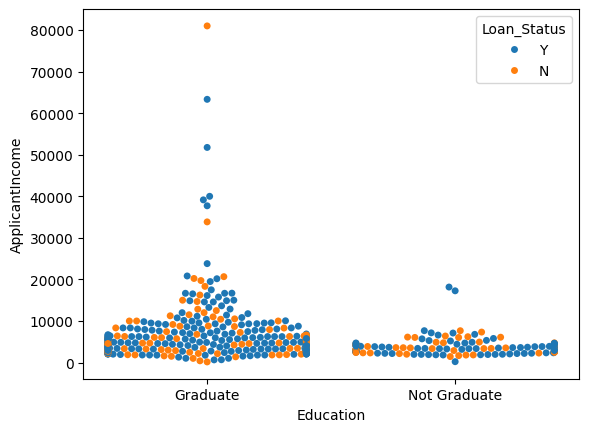

In [27]:
sns.swarmplot(x='Education', y='ApplicantIncome', hue='Loan_Status', data=df)
plt.show()

In [38]:
print("Missing values before:\n", df.isnull().sum())

Missing values before:
 Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [39]:
# Fix 'Dependents' column — replace '3+' with 3
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

# Now fill missing values in Dependents using mode
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

In [40]:
df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mean(), inplace=True)


In [41]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [42]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

In [43]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [44]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nDataset after encoding:\n", df.head())


Dataset after encoding:
    Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0  146.412162             360.0             1.0   
1             1508.0  128.000000             360.0             1.0   
2                0.0   66.000000             360.0             1.0   
3             2358.0  120.000000             360.0             1.0   
4                0.0  141.000000             360.0             1.0   

   Property_Area  Loan_Status  
0              2            1  
1              0          

In [45]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Story 2: Balance the dataset with SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)
print("Balanced class distribution:", pd.Series(y_resampled).value_counts())

# Story 3: Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# Story 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")


Balanced class distribution: Loan_Status
1    422
0    422
Name: count, dtype: int64

Train size: (675, 11), Test size: (169, 11)



Model: Decision Tree
Accuracy: 0.7751
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        94
           1       0.73      0.79      0.76        75

    accuracy                           0.78       169
   macro avg       0.77      0.78      0.77       169
weighted avg       0.78      0.78      0.78       169


Model: Random Forest
Accuracy: 0.8047
              precision    recall  f1-score   support

           0       0.91      0.72      0.80        94
           1       0.72      0.91      0.80        75

    accuracy                           0.80       169
   macro avg       0.82      0.82      0.80       169
weighted avg       0.83      0.80      0.80       169


Model: KNN
Accuracy: 0.7101
              precision    recall  f1-score   support

           0       0.79      0.65      0.71        94
           1       0.64      0.79      0.71        75

    accuracy                           0.71       169
   macro avg       0.

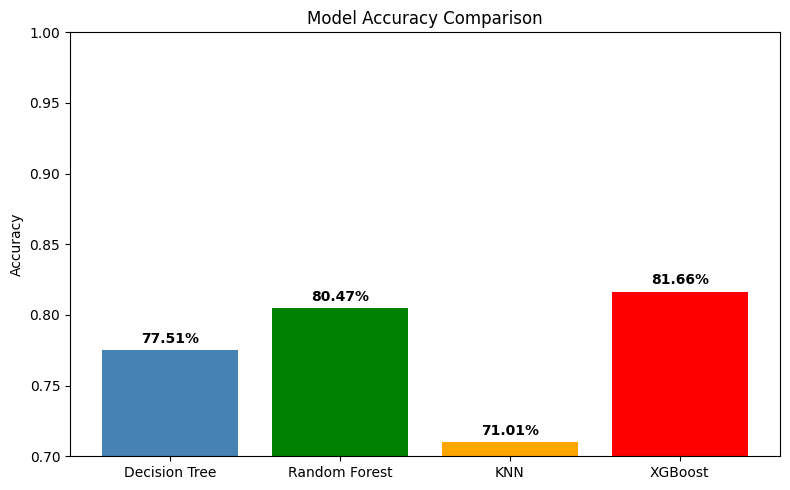


Best Model: XGBoost with accuracy 0.8166
Model and scaler saved successfully!


In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

# --- Compare all models ---
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['steelblue', 'green', 'orange', 'red'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.005, f"{v:.2%}", ha='center', fontweight='bold')
plt.tight_layout()

plt.show()

# --- Save the Best Model ---
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name} with accuracy {results[best_model_name]:.4f}")

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

In [55]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1
5,1,1,2,0,1,5417,4196.0,267.000000,360.0,1.0,2,1
6,1,1,0,1,0,2333,1516.0,95.000000,360.0,1.0,2,1
7,1,1,3,0,0,3036,2504.0,158.000000,360.0,0.0,1,0
8,1,1,2,0,0,4006,1526.0,168.000000,360.0,1.0,2,1
9,1,1,1,0,0,12841,10968.0,349.000000,360.0,1.0,1,0


In [56]:
import numpy as np

sample = np.array([[1,	1,	3,	0,	0,	3036,	2504.0,	158.000000,	360.0,	0.0,	1]])
sample_scaled = scaler.transform(sample)

prediction = best_model.predict(sample_scaled)
probability = best_model.predict_proba(sample_scaled)
print("Prediction:", "LOAN APPROVED" if prediction[0] == 1 else " LOAN NOT APPROVED")


Prediction:  LOAN NOT APPROVED


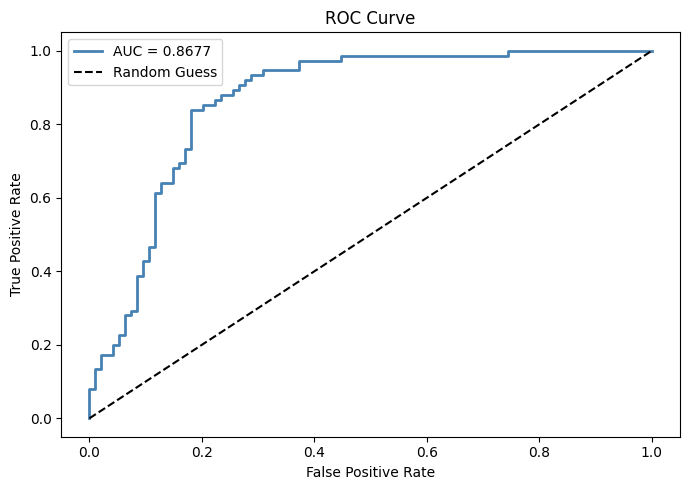

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='steelblue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()
